In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib import colors
from matplotlib import rc
import matplotlib.patches as mpatches
from Tools.Utils import calculate_mouse_centers, calculate_mouse_distance

def load_task1_data(data_path):
  """
  Load data for task 1:
      The vocaubulary tells you how to map behavior names to class ids;
      it is the same for all sequences in this dataset.
  """
  data_dict = np.load(data_path, allow_pickle=True).item()
  dataset = data_dict['annotator-id_0']
  # Get any sequence key.
  sequence_id = list(data_dict['annotator-id_0'].keys())[0]
  vocabulary = data_dict['annotator-id_0'][sequence_id]['metadata']['vocab']
  return dataset, vocabulary

# training_data, vocab = load_task1_data('./Caltech/calms21_task1_train.npy')
training_data, vocab = load_task1_data('./Caltech/calms21_task1_train_distance_lt_330.npy')
test_data, _ = load_task1_data('./Caltech/calms21_task1_test.npy')


# Helper functions for visualization

rc('animation', html='jshtml')

# Note: Image processing may be slow if too many frames are animated.

# Plotting constants
FRAME_WIDTH_TOP = 1024
FRAME_HEIGHT_TOP = 570

RESIDENT_COLOR = 'lawngreen'
INTRUDER_COLOR = 'skyblue'

PLOT_MOUSE_START_END = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4),
                        (3, 5), (4, 6), (5, 6), (1, 2)]
class_to_color = {'other': 'white', 'attack' : 'red', 'mount' : 'green',
                  'investigation': 'orange'}
class_to_number = {s: i for i, s in enumerate(vocab)}
number_to_class = {i: s for i, s in enumerate(vocab)}


def num_to_text(anno_list):
  return np.vectorize(number_to_class.get)(anno_list)


def set_figax():
  fig = plt.figure(figsize=(6, 4))

  img = np.zeros((FRAME_HEIGHT_TOP, FRAME_WIDTH_TOP, 3))

  ax = fig.add_subplot(111)
  ax.imshow(img)

  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  return fig, ax


def plot_mouse(ax, pose, color):
  # Draw each keypoint
  for j in range(7):
    ax.plot(pose[j, 0], pose[j, 1], 'o', color=color, markersize=5)

  # Draw a line for each point pair to form the shape of the mouse

  for pair in PLOT_MOUSE_START_END:
    line_to_plot = pose[pair, :]
    ax.plot(line_to_plot[:, 0], line_to_plot[
            :, 1], color=color, linewidth=1)

  # Draw the center point averaged over all keypoints
  center = np.nanmean(pose, axis=0)
  ax.plot(center[0], center[1], marker='X', color=color,
          markeredgecolor='white', markeredgewidth=1.5,
          markersize=9, zorder=4)


def animate_pose_sequence(video_name, keypoint_sequence, start_frame = 0, stop_frame = 100,
                          annotation_sequence = None, mse_sequence = None):
  # Returns the animation of the keypoint sequence between start frame
  # and stop frame. Optionally can display annotations.
  seq = keypoint_sequence.transpose((0,1,3,2))
  center_sequence = calculate_mouse_centers(keypoint_sequence)
  distance_sequence = calculate_mouse_distance(keypoint_sequence)

  image_list = []

  counter = 0
  for j in range(start_frame, stop_frame):
    if counter%20 == 0:
      print("Processing frame ", j)
    fig, ax = set_figax()
    plot_mouse(ax, seq[j, 0, :, :], color=RESIDENT_COLOR)
    plot_mouse(ax, seq[j, 1, :, :], color=INTRUDER_COLOR)

    centers = center_sequence[j]
    ax.plot(centers[:, 0], centers[:, 1], color='white', linestyle='--',
            linewidth=1.5, alpha=0.9, zorder=2)
    plt.text(50, 20, 'distance: {:.1f} px'.format(distance_sequence[j]),
             fontsize=12, color='white',
             bbox=dict(facecolor='black', edgecolor='white', alpha=0.6))

    if annotation_sequence is not None:
      annot = annotation_sequence[j]
      annot = number_to_class[annot]
      plt.text(50, -20, annot, fontsize=16,
               bbox=dict(facecolor=class_to_color[annot], alpha=0.5))

    # Show per-frame MSE when rollout prediction errors are provided.
    # ???? rollout ??????????????? MSE?
    if mse_sequence is not None:
      mse_value = mse_sequence[j - start_frame]
      plt.text(50, 55, 'MSE: {:.2f}'.format(mse_value),
               fontsize=12, color='white',
               bbox=dict(facecolor='black', edgecolor='white', alpha=0.6))

    ax.set_title(
        video_name + '\n frame {:03d}.png'.format(j))

    ax.axis('off')
    fig.tight_layout(pad=0)
    ax.margins(0)

    fig.canvas.draw()
    # image_from_plot = np.frombuffer(fig.canvas.tostring_rgb(),
    #                                 dtype=np.uint8)
    # image_from_plot = image_from_plot.reshape(
    #     fig.canvas.get_width_height()[::-1] + (3,))
    image_from_plot = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]

    image_list.append(image_from_plot)

    plt.close()
    counter = counter + 1

  # Plot animation.
  fig = plt.figure()
  plt.axis('off')
  im = plt.imshow(image_list[0])

  def animate(k):
      im.set_array(image_list[k])
      return im,
  ani = animation.FuncAnimation(fig, animate, frames=len(image_list), blit=True)
  # Close the static Matplotlib figure so Jupyter only displays the animation.
  # ???? Matplotlib ????? Jupyter ????????
  plt.close(fig)
  return ani


def plot_behavior_raster(annotation_sequence, start_frame=0,
                         stop_frame=100,
                         title="Behavior Labels"):
  # Plot annotations as a behavior raster

  # Map annotations to a number.
  annotation_num = []
  for item in annotation_sequence[start_frame:stop_frame]:
    annotation_num.append(class_to_number[item])

  all_classes = list(set(annotation_sequence[start_frame:stop_frame]))

  cmap = colors.ListedColormap(['red', 'orange', 'green', 'white'])
  bounds=[-0.5, 0.5, 1.5, 2.5, 3.5]
  norm = colors.BoundaryNorm(bounds, cmap.N)

  height = 200
  arr_to_plot = np.repeat(np.array(annotation_num)[:, np.newaxis].transpose(),
                                                  height, axis = 0)

  fig, ax = plt.subplots(figsize = (16, 3))
  ax.imshow(arr_to_plot, interpolation='none',cmap=cmap, norm=norm)

  ax.set_yticks([])
  ax.set_xlabel('Frame Number')
  plt.title(title)

  legend_patches = []
  for item in all_classes:
    legend_patches.append(mpatches.Patch(color=class_to_color[item], label=item))

  plt.legend(handles=legend_patches,loc='center left', bbox_to_anchor=(1, 0.5))

  plt.tight_layout()

rollout_path: Model/asymmetric_pose_case/runs/20260718_081453_asymmetric_pose/fold_01/rollouts/mouse003_start30_len50.npz
sequence_id: task1/train/mouse003_task1_annotator1
target frames: 30 to 79
keypoints_pred_pair shape: (50, 2, 2, 7)


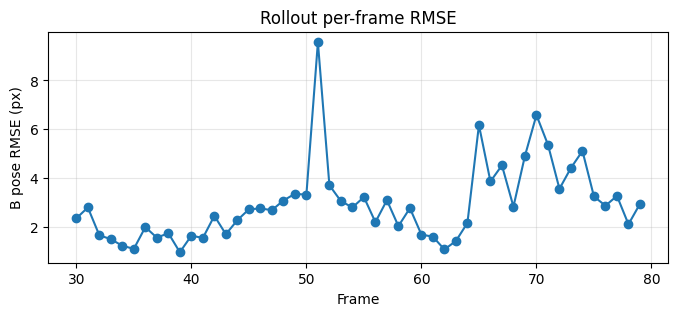

Processing frame  0
Processing frame  20
Processing frame  40


Processing frame  0
Processing frame  20
Processing frame  40


In [2]:
# Visualize rollout prediction results produced by validation/rollout.py
# ??? validation/rollout.py ?????????
from pathlib import Path
from IPython.display import display, HTML


# "Model/asymmetric_pose_case/runs/20260711_090246_baseline_lstm_10epochs/"
# "fold_01/rollouts/mouse003_start100_len20.npz"
rollout_path = Path(
    "Model/asymmetric_pose_case/runs/20260718_081453_asymmetric_pose/"
    "fold_01/rollouts/mouse003_start30_len50.npz"
)

rollout = np.load(rollout_path, allow_pickle=True)

# keypoints_pred_pair follows the CalMS21 format: [frame, mouse, coord, joint].
# keypoints_pred_pair ?? CalMS21 ?????[?, ??, ??, ??]?
keypoints_pred_pair = rollout["keypoints_pred_pair"]
a_pose_xy = rollout["a_pose_xy"]
b_true_pose_xy = rollout["b_true_pose_xy"]
per_frame_rmse = rollout["per_frame_rmse"]
per_frame_mse = rollout["per_frame_mse"]
target_t = rollout["target_t"]
sequence_id = str(rollout["sequence_id"])
rollout_length = int(rollout["rollout_length"])

print("rollout_path:", rollout_path)
print("sequence_id:", sequence_id)
print("target frames:", target_t[0], "to", target_t[-1])
print("keypoints_pred_pair shape:", keypoints_pred_pair.shape)

# Build the true comparison pair in the same CalMS21 format.
# ?????????????? CalMS21 ???
def build_pair_keypoints(a_pose_xy, b_pose_xy):
    pair = np.empty((a_pose_xy.shape[0], 2, 2, 7), dtype=np.float32)
    pair[:, 0] = np.transpose(a_pose_xy, (0, 2, 1))
    pair[:, 1] = np.transpose(b_pose_xy, (0, 2, 1))
    return pair

keypoints_true_pair = build_pair_keypoints(a_pose_xy, b_true_pose_xy)

# Load the real annotations for the rollout frames.
# ?? rollout ???????? annotation????????
rollout_dataset, rollout_vocab = load_task1_data("./Caltech/calms21_task1_train_distance_lt_330.npy")
annotation_sequence = rollout_dataset[sequence_id]["annotations"][target_t]

# Plot per-frame rollout RMSE before the animations.
# ??????????? RMSE?????????? rollout ???
plt.figure(figsize=(8, 3))
plt.plot(target_t, per_frame_rmse, marker="o")
plt.xlabel("Frame")
plt.ylabel("B pose RMSE (px)")
plt.title("Rollout per-frame RMSE")
plt.grid(alpha=0.3)
plt.show()

# Animation 1: true A + predicted B. This is the main visualization output.
# ?? 1??? A + ?? B???????????
ani_pred = animate_pose_sequence(
    "Rollout prediction: true A + predicted B",
    keypoints_pred_pair,
    start_frame=0,
    stop_frame=rollout_length,
    annotation_sequence=annotation_sequence,
    mse_sequence=per_frame_mse,
)
# ani_pred
display(HTML(ani_pred.to_jshtml()))

# Animation 2: true A + true B, for side-by-side qualitative comparison.
# ?? 2??? A + ?? B??????????????
ani_true = animate_pose_sequence(
    "Ground truth: true A + true B",
    keypoints_true_pair,
    start_frame=0,
    stop_frame=rollout_length,
    annotation_sequence=annotation_sequence,
)
# ani_true
display(HTML(ani_true.to_jshtml()))


In [ ]:
JOINT_NAMES = ["nose", "ear_L", "ear_R", "neck", "hip_L", "hip_R", "tail"]

def plot_joint_trajectories(true_pose_xy, pred_pose_xy, target_t, joint_ids=None):
    if joint_ids is None:
        joint_ids = range(true_pose_xy.shape[1])

    n = len(joint_ids)
    fig, axes = plt.subplots(n, 2, figsize=(12, 2.5 * n), sharex=True)

    if n == 1:
        axes = np.array([axes])

    for row, joint_id in enumerate(joint_ids):
        joint_name = JOINT_NAMES[joint_id]

        axes[row, 0].plot(target_t, true_pose_xy[:, joint_id, 0], label="true x", linewidth=2)
        axes[row, 0].plot(target_t, pred_pose_xy[:, joint_id, 0], label="pred x", linestyle="--")
        axes[row, 0].set_ylabel(f"{joint_name} x")
        axes[row, 0].grid(alpha=0.3)

        axes[row, 1].plot(target_t, true_pose_xy[:, joint_id, 1], label="true y", linewidth=2)
        axes[row, 1].plot(target_t, pred_pose_xy[:, joint_id, 1], label="pred y", linestyle="--")
        axes[row, 1].set_ylabel(f"{joint_name} y")
        axes[row, 1].grid(alpha=0.3)

    axes[0, 0].legend()
    axes[0, 1].legend()
    axes[-1, 0].set_xlabel("Frame")
    axes[-1, 1].set_xlabel("Frame")

    fig.suptitle("True vs Predicted Joint Coordinates", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_joint_trajectories(
    rollout["b_true_pose_xy"],
    rollout["b_pred_pose_xy"],
    rollout["target_t"],
    joint_ids=[0, 3, 6],
)

In [ ]:
def plot_mean_error_by_joint(per_joint_l2):
    mean_error = per_joint_l2.mean(axis=0)
    std_error = per_joint_l2.std(axis=0)

    plt.figure(figsize=(9, 4))
    plt.bar(JOINT_NAMES, mean_error, yerr=std_error, capsize=4)
    plt.ylabel("Mean L2 error, pixels")
    plt.title("Average Prediction Error By Joint")
    plt.grid(axis="y", alpha=0.3)
    plt.show()


plot_mean_error_by_joint(rollout["per_joint_l2"])

In [ ]:
def plot_error_heatmap(per_joint_l2, target_t):
    plt.figure(figsize=(12, 4))
    plt.imshow(per_joint_l2.T, aspect="auto", cmap="magma", interpolation="nearest")

    plt.colorbar(label="L2 error, pixels")
    plt.yticks(np.arange(len(JOINT_NAMES)), JOINT_NAMES)

    tick_positions = np.linspace(0, len(target_t) - 1, min(8, len(target_t))).astype(int)
    plt.xticks(tick_positions, target_t[tick_positions])

    plt.xlabel("Frame")
    plt.ylabel("Joint")
    plt.title("Prediction Error Heatmap")
    plt.tight_layout()
    plt.show()


plot_error_heatmap(rollout["per_joint_l2"], rollout["target_t"])

In [ ]:
def plot_pose_error_vectors(true_pose_xy, pred_pose_xy, frame_idx, title=None):
    true_pose = true_pose_xy[frame_idx]
    pred_pose = pred_pose_xy[frame_idx]

    plt.figure(figsize=(7, 5))
    ax = plt.gca()
    ax.set_facecolor("black")

    for a, b in PLOT_MOUSE_START_END:
        plt.plot(
            [true_pose[a, 0], true_pose[b, 0]],
            [true_pose[a, 1], true_pose[b, 1]],
            color="white",
            linewidth=2,
            alpha=0.8,
            label="true" if a == 0 and b == 1 else None,
        )

        plt.plot(
            [pred_pose[a, 0], pred_pose[b, 0]],
            [pred_pose[a, 1], pred_pose[b, 1]],
            color="cyan",
            linewidth=2,
            linestyle="--",
            alpha=0.8,
            label="predicted" if a == 0 and b == 1 else None,
        )

    for j in range(true_pose.shape[0]):
        plt.scatter(true_pose[j, 0], true_pose[j, 1], color="white", s=35)
        plt.scatter(pred_pose[j, 0], pred_pose[j, 1], color="cyan", s=35)

        dx = pred_pose[j, 0] - true_pose[j, 0]
        dy = pred_pose[j, 1] - true_pose[j, 1]
        plt.arrow(
            true_pose[j, 0],
            true_pose[j, 1],
            dx,
            dy,
            color="red",
            width=0.4,
            head_width=4,
            length_includes_head=True,
            alpha=0.8,
        )

        plt.text(true_pose[j, 0] + 4, true_pose[j, 1] + 4, JOINT_NAMES[j], color="white")

    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.legend()
    plt.title(title or f"Pose Error Vectors, rollout frame {frame_idx}")
    plt.tight_layout()
    plt.show()


worst_frame = int(np.argmax(rollout["per_frame_rmse"]))

plot_pose_error_vectors(
    rollout["b_true_pose_xy"],
    rollout["b_pred_pose_xy"],
    worst_frame,
    title=f"Worst Frame Error Vectors, frame {rollout['target_t'][worst_frame]}",
)

In [ ]:
def plot_best_median_worst_frames(true_pose_xy, pred_pose_xy, per_frame_rmse, target_t):
    order = np.argsort(per_frame_rmse)
    selected = [
        ("Best", int(order[0])),
        ("Median", int(order[len(order) // 2])),
        ("Worst", int(order[-1])),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, (label, idx) in zip(axes, selected):
        true_pose = true_pose_xy[idx]
        pred_pose = pred_pose_xy[idx]

        ax.set_facecolor("black")

        for a, b in PLOT_MOUSE_START_END:
            ax.plot(
                [true_pose[a, 0], true_pose[b, 0]],
                [true_pose[a, 1], true_pose[b, 1]],
                color="white",
                linewidth=2,
                label="true" if a == 0 and b == 1 else None,
            )
            ax.plot(
                [pred_pose[a, 0], pred_pose[b, 0]],
                [pred_pose[a, 1], pred_pose[b, 1]],
                color="cyan",
                linewidth=2,
                linestyle="--",
                label="predicted" if a == 0 and b == 1 else None,
            )

        ax.scatter(true_pose[:, 0], true_pose[:, 1], color="white", s=35)
        ax.scatter(pred_pose[:, 0], pred_pose[:, 1], color="cyan", s=35)

        ax.invert_yaxis()
        ax.axis("equal")
        ax.set_title(
            f"{label}\nframe {target_t[idx]}, RMSE={per_frame_rmse[idx]:.2f}px",
            color="black",
        )

    axes[0].legend()
    plt.tight_layout()
    plt.show()


plot_best_median_worst_frames(
    rollout["b_true_pose_xy"],
    rollout["b_pred_pose_xy"],
    rollout["per_frame_rmse"],
    rollout["target_t"],
)

In [ ]:
def plot_error_vs_mouse_distance(keypoints_true_pair, per_frame_rmse, target_t):
    distances = calculate_mouse_distance(keypoints_true_pair)

    plt.figure(figsize=(7, 5))
    plt.scatter(distances, per_frame_rmse, c=target_t, cmap="viridis", s=45)
    plt.colorbar(label="Frame")
    plt.xlabel("Resident-intruder center distance, pixels")
    plt.ylabel("Prediction RMSE, pixels")
    plt.title("Prediction Error vs Mouse Distance")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_vs_mouse_distance(
    rollout["keypoints_true_pair"],
    rollout["per_frame_rmse"],
    rollout["target_t"],
)

In [ ]:
def plot_error_by_behavior(annotation_sequence, per_frame_rmse):
    labels = np.array([number_to_class[int(a)] for a in annotation_sequence])

    unique_labels = sorted(set(labels))
    grouped = [per_frame_rmse[labels == label] for label in unique_labels]

    plt.figure(figsize=(8, 4))
    plt.boxplot(grouped, labels=unique_labels, showmeans=True)
    plt.ylabel("RMSE, pixels")
    plt.title("Prediction Error By Behavior")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_by_behavior(annotation_sequence, rollout["per_frame_rmse"])

In [ ]:
def plot_delta_norms(true_delta_xy, pred_delta_xy, target_t):
    true_speed = np.linalg.norm(true_delta_xy, axis=-1).mean(axis=1)
    pred_speed = np.linalg.norm(pred_delta_xy, axis=-1).mean(axis=1)

    plt.figure(figsize=(10, 4))
    plt.plot(target_t, true_speed, label="true mean joint movement", linewidth=2)
    plt.plot(target_t, pred_speed, label="predicted mean joint movement", linestyle="--")
    plt.xlabel("Frame")
    plt.ylabel("Mean joint delta magnitude, pixels/frame")
    plt.title("True vs Predicted Pose Movement")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_delta_norms(
    rollout["b_true_delta_xy"],
    rollout["b_pred_delta_xy"],
    rollout["target_t"],
)

In [ ]:
def plot_cumulative_error(per_frame_rmse, target_t):
    cumulative = np.cumsum(per_frame_rmse)

    plt.figure(figsize=(10, 4))
    plt.plot(target_t, cumulative, linewidth=2)
    plt.xlabel("Frame")
    plt.ylabel("Cumulative RMSE")
    plt.title("Cumulative Prediction Error Across Rollout")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_cumulative_error(rollout["per_frame_rmse"], rollout["target_t"])

In [ ]:
def plot_error_vs_time_from_trial_start(rollout):
    target_t = rollout["target_t"]
    rmse = rollout["per_frame_rmse"]

    plt.figure(figsize=(9, 4))
    plt.plot(target_t, rmse, marker="o", linewidth=2)
    plt.xlabel("Frame index in trial/window")
    plt.ylabel("Pose RMSE, pixels")
    plt.title("Prediction Error vs Time From Trial Start")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_vs_time_from_trial_start(rollout)

In [ ]:
def compute_mean_joint_speed(pose_xy):
    delta = np.diff(pose_xy, axis=0)
    speed = np.linalg.norm(delta, axis=-1).mean(axis=1)
    speed = np.concatenate([[np.nan], speed])
    return speed


def plot_error_vs_target_speed(rollout):
    true_pose = rollout["b_true_pose_xy"]
    rmse = rollout["per_frame_rmse"]
    speed = compute_mean_joint_speed(true_pose)

    valid = ~np.isnan(speed)

    plt.figure(figsize=(7, 5))
    plt.scatter(speed[valid], rmse[valid], c=rollout["target_t"][valid], cmap="viridis", s=45)
    plt.colorbar(label="Frame")
    plt.xlabel("Target mouse mean joint speed, pixels/frame")
    plt.ylabel("Pose RMSE, pixels")
    plt.title("Prediction Error vs Target Mouse Speed")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_vs_target_speed(rollout)

In [ ]:
def compute_mean_joint_acceleration(pose_xy):
    velocity = np.diff(pose_xy, axis=0)
    acceleration = np.diff(velocity, axis=0)
    accel_mag = np.linalg.norm(acceleration, axis=-1).mean(axis=1)
    accel_mag = np.concatenate([[np.nan, np.nan], accel_mag])
    return accel_mag


def plot_error_vs_acceleration(rollout):
    true_pose = rollout["b_true_pose_xy"]
    rmse = rollout["per_frame_rmse"]
    accel = compute_mean_joint_acceleration(true_pose)

    valid = ~np.isnan(accel)

    plt.figure(figsize=(7, 5))
    plt.scatter(accel[valid], rmse[valid], c=rollout["target_t"][valid], cmap="plasma", s=45)
    plt.colorbar(label="Frame")
    plt.xlabel("Target mouse mean joint acceleration, pixels/frame²")
    plt.ylabel("Pose RMSE, pixels")
    plt.title("Prediction Error vs Motion Abruptness")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_vs_acceleration(rollout)

In [ ]:
def plot_error_vs_mouse_distance(rollout):
    distances = calculate_mouse_distance(rollout["keypoints_true_pair"])
    rmse = rollout["per_frame_rmse"]

    plt.figure(figsize=(7, 5))
    plt.scatter(distances, rmse, c=rollout["target_t"], cmap="viridis", s=45)
    plt.colorbar(label="Frame")
    plt.xlabel("Mouse center distance, pixels")
    plt.ylabel("Pose RMSE, pixels")
    plt.title("Prediction Error vs Mouse-Mouse Distance")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_vs_mouse_distance(rollout)

In [ ]:
def compute_heading_angle(pose_xy):
    nose = pose_xy[:, 0, :]
    neck = pose_xy[:, 3, :]
    heading = nose - neck
    return np.arctan2(heading[:, 1], heading[:, 0])


def angular_difference(a, b):
    return np.arctan2(np.sin(a - b), np.cos(a - b))


def plot_error_vs_relative_heading(rollout):
    resident = rollout["resident_true_pose_xy"]
    intruder = rollout["intruder_true_pose_xy"]

    resident_angle = compute_heading_angle(resident)
    intruder_angle = compute_heading_angle(intruder)

    relative_heading = np.abs(angular_difference(intruder_angle, resident_angle))
    relative_heading_deg = np.degrees(relative_heading)

    rmse = rollout["per_frame_rmse"]

    plt.figure(figsize=(7, 5))
    plt.scatter(relative_heading_deg, rmse, c=rollout["target_t"], cmap="magma", s=45)
    plt.colorbar(label="Frame")
    plt.xlabel("Absolute relative heading, degrees")
    plt.ylabel("Pose RMSE, pixels")
    plt.title("Prediction Error vs Relative Mouse Heading")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_vs_relative_heading(rollout)

In [ ]:
def frames_since_behavior_change(annotation_sequence):
    annotation_sequence = np.asarray(annotation_sequence)
    out = np.zeros(len(annotation_sequence), dtype=int)

    last_change = 0
    for i in range(1, len(annotation_sequence)):
        if annotation_sequence[i] != annotation_sequence[i - 1]:
            last_change = i
        out[i] = i - last_change

    return out


def plot_error_vs_time_since_behavior_change(annotation_sequence, rmse):
    since_change = frames_since_behavior_change(annotation_sequence)

    plt.figure(figsize=(7, 5))
    plt.scatter(since_change, rmse, s=45)
    plt.xlabel("Frames since last behavior-label change")
    plt.ylabel("Pose RMSE, pixels")
    plt.title("Prediction Error vs Time Since Behavior Transition")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_vs_time_since_behavior_change(
    annotation_sequence,
    rollout["per_frame_rmse"],
)

In [ ]:
def plot_error_by_behavior(annotation_sequence, rmse):
    labels = np.array([number_to_class[int(a)] for a in annotation_sequence])
    unique_labels = sorted(set(labels))

    grouped = [rmse[labels == label] for label in unique_labels]

    plt.figure(figsize=(8, 4))
    plt.boxplot(grouped, labels=unique_labels, showmeans=True)
    plt.ylabel("Pose RMSE, pixels")
    plt.title("Prediction Error By Behavior Class")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_by_behavior(annotation_sequence, rollout["per_frame_rmse"])

In [ ]:
def autocorrelation(x, max_lag=20):
    x = np.asarray(x)
    x = x - np.mean(x)

    values = []
    for lag in range(max_lag + 1):
        if lag == 0:
            values.append(1.0)
        else:
            values.append(np.corrcoef(x[:-lag], x[lag:])[0, 1])

    return np.array(values)


def plot_error_autocorrelation(rollout, max_lag=20):
    ac = autocorrelation(rollout["per_frame_rmse"], max_lag=max_lag)
    lags = np.arange(max_lag + 1)

    plt.figure(figsize=(8, 4))
    plt.stem(lags, ac)
    plt.xlabel("Lag, frames")
    plt.ylabel("Autocorrelation")
    plt.title("Temporal Autocorrelation Of Prediction Error")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_error_autocorrelation(rollout, max_lag=20)

In [ ]:
def plot_joint_errors_over_time(rollout):
    per_joint_l2 = rollout["per_joint_l2"]
    target_t = rollout["target_t"]

    plt.figure(figsize=(11, 5))

    for j, name in enumerate(JOINT_NAMES):
        plt.plot(target_t, per_joint_l2[:, j], label=name)

    plt.xlabel("Frame")
    plt.ylabel("Joint L2 error, pixels")
    plt.title("Joint-Specific Prediction Error Over Time")
    plt.legend(ncol=4)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_joint_errors_over_time(rollout)